# 02_preprocessing.ipynb

## Purpose
Transform raw ECG signals (from `01_data_loading`) into 
**clean, normalized, windowed forecasting arrays** ready for 
deep learning models.

## Pipeline Steps
| Step | Operation | Leakage Risk | How We Handle It |
|------|-----------|-------------|-----------------|
| 1 | Load raw signals | — | Read from disk |
| 2 | NaN interpolation | Low | Per-record, no global stats |
| 3 | Outlier clipping | Low | Per-record ±3σ |
| 4 | Bandpass filter | None | Signal processing only |
| 5 | **Train/Val/Test split** | **Critical** | **Split happens HERE before any statistics** |
| 6 | Normalization | **Critical** | **Train stats only → applied to all splits** |
| 7 | Window construction | Medium | Windows built per-split separately |
| 8 | Horizon experiments | None | Analysis only |
| 9 | PCA analysis | None | Fit on train only |
| 10 | Augmentation | None | Train inputs only, targets unchanged |
| 11 | Sanity checks | — | Assertions + prints |
| 12 | Save outputs | — | All artifacts to `data/processed/` |

## Key Leakage Prevention Rule
> **Split FIRST. Normalize SECOND. Never the other way around.**

If normalization happens before splitting, the mean/std computed 
on the full dataset encodes information from validation and test 
records into the training normalization parameters. This is 
**data leakage** and leads to optimistically biased evaluation.

## Pipeline Position
01_data_loading → **[02_preprocessing]** → 03_eda → 04_modeling

In [19]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt, welch
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────
SAVE_DIR = os.path.join('..', 'data', 'processed')
FIG_DIR  = os.path.join('..', 'reports', 'figures')
os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Signal config ──────────────────────────────────────────
FS      = 100
N_LEADS = 12
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF',
              'V1','V2','V3','V4','V5','V6']

# ── Forecasting config (change only here) ─────────────────
#   INPUT_LEN : history given to model (samples)
#   HORIZON   : future steps to predict (samples)
#   STRIDE    : step between windows (samples)
#
#   At 100 Hz:
#     500 samples = 5.0 seconds
#     100 samples = 1.0 second
INPUT_LEN = 500
HORIZON   = 100
STRIDE    = 100

# ── Reproducibility ────────────────────────────────────────
SEED = 42
RNG  = np.random.default_rng(seed=SEED)
np.random.seed(SEED)

print("Imports & config OK ✅")
print(f"  SAVE_DIR  : {os.path.abspath(SAVE_DIR)}")
print(f"  FIG_DIR   : {os.path.abspath(FIG_DIR)}")
print(f"  FS        : {FS} Hz")
print(f"  INPUT_LEN : {INPUT_LEN} samples = {INPUT_LEN/FS:.1f}s")
print(f"  HORIZON   : {HORIZON} samples = {HORIZON/FS:.1f}s")
print(f"  STRIDE    : {STRIDE} samples")
print(f"  SEED      : {SEED}")

Imports & config OK ✅
  SAVE_DIR  : /Users/muhammadfahadsiddiqui/HIS Project/data/processed
  FIG_DIR   : /Users/muhammadfahadsiddiqui/HIS Project/reports/figures
  FS        : 100 Hz
  INPUT_LEN : 500 samples = 5.0s
  HORIZON   : 100 samples = 1.0s
  STRIDE    : 100 samples
  SEED      : 42


### Loading from disk
We load artifacts saved by `01_data_loading.ipynb`.  
**No downloading, no streaming** — just `np.load()` from disk.

If files are missing, run `01_data_loading.ipynb` first.

In [20]:
required_files = ['X_raw.npy', 'metadata.pkl']
for fname in required_files:
    fpath = os.path.join(SAVE_DIR, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(
            f"Required file not found: {fpath}\n"
            "Please run 01_data_loading.ipynb first."
        )

X_raw    = np.load(os.path.join(SAVE_DIR, 'X_raw.npy'))
df       = pd.read_pickle(os.path.join(SAVE_DIR, 'metadata.pkl'))
batch_df = df.iloc[:len(X_raw)].copy().reset_index(drop=False)

assert len(X_raw) == len(batch_df), (
    f"Mismatch: X_raw={len(X_raw)} but metadata={len(batch_df)}"
)

print("=" * 60)
print("  RAW DATA LOADED")
print("=" * 60)
print(f"  X_raw shape   : {X_raw.shape}")
print(f"                → (records, samples, leads)")
print(f"  Metadata rows : {batch_df.shape}")
print(f"  Strat folds   : {sorted(batch_df['strat_fold'].unique())}")
print(f"  Alignment     : ✅ {len(X_raw):,} records matched")

  RAW DATA LOADED
  X_raw shape   : (21799, 1000, 12)
                → (records, samples, leads)
  Metadata rows : (21799, 29)
  Strat folds   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  Alignment     : ✅ 21,799 records matched


### NaN Handling

PTB-XL is a clean dataset — NaN values are rare but can occur 
from sensor dropouts or corrupted records.

**Strategy**: Linear interpolation per lead per record.  
- Isolated NaNs → interpolated from neighbours  
- Edge NaNs → filled forward/backward  
- All-NaN lead → left as zero (flagged separately)

This is applied **before** the train/val/test split because it 
is a deterministic signal operation with no statistical parameters 
— it cannot cause leakage.

In [21]:
# Safe to do before split — uses no cross-record statistics.
# Linear interpolation per lead per record.

total_nan = int(np.isnan(X_raw).sum())
print(f"NaN values detected: {total_nan:,}")

if total_nan > 0:
    X_interp  = X_raw.copy()
    nan_count = 0
    for rec_idx in range(X_interp.shape[0]):
        for lead_idx in range(X_interp.shape[2]):
            series = pd.Series(X_interp[rec_idx, :, lead_idx])
            if series.isna().any():
                X_interp[rec_idx, :, lead_idx] = (
                    series
                    .interpolate(method='linear',
                                 limit_direction='both')
                    .values
                )
                nan_count += 1
    remaining = int(np.isnan(X_interp).sum())
    print(f"  Lead-records interpolated : {nan_count:,}")
    print(f"  Remaining NaN             : {remaining}")
    assert remaining == 0, "NaN still present after interpolation"
    print("  ✅ All NaN resolved")
else:
    X_interp = X_raw.copy()
    print("  ✅ No NaN — signals are clean")

NaN values detected: 0
  ✅ No NaN — signals are clean


### Step 3 — Sampling Rate Consistency Check

In [22]:
n_samples        = X_interp.shape[1]
expected_samples = FS * 10

print("=" * 60)
print("  SAMPLING RATE CONSISTENCY")
print("=" * 60)
print(f"  Expected : {expected_samples} samples ({FS} Hz × 10s)")
print(f"  Actual   : {n_samples} samples")

if n_samples == expected_samples:
    print(f"  ✅ {FS} Hz confirmed")
    assert INPUT_LEN + HORIZON <= n_samples, (
        f"INPUT_LEN + HORIZON = {INPUT_LEN + HORIZON} "
        f"> {n_samples} available samples"
    )
    print(f"  ✅ Window {INPUT_LEN} + horizon {HORIZON} "
          f"= {INPUT_LEN+HORIZON} ≤ {n_samples} ✓")
else:
    raise ValueError(
        f"Unexpected {n_samples} samples. "
        f"Expected {expected_samples} for {FS} Hz data."
    )

  SAMPLING RATE CONSISTENCY
  Expected : 1000 samples (100 Hz × 10s)
  Actual   : 1000 samples
  ✅ 100 Hz confirmed
  ✅ Window 500 + horizon 100 = 600 ≤ 1000 ✓


### Outlier Clipping

Extreme amplitude values in ECG recordings typically arise from:
- Electrode contact problems (sudden spikes)
- Patient movement artefacts  
- Lead disconnect events

**Strategy**: Clip each lead of each record to ±3σ of that 
lead's own distribution.

- Operates **per-record per-lead** → preserves relative amplitudes
- Clipping threshold computed locally → no global statistics needed
- Typical clip rate: < 0.3% of samples
- ECG morphology (QRS shape, T-wave) is preserved

This step has **no leakage risk** because statistics are computed 
locally on each individual record, not across records.

In [23]:
# ============================================================
# CELL 5 (FINAL FIX): TWO-STAGE OUTLIER CLIPPING
# ============================================================

MV_HARD_CLIP = 5.0  # physiological hard limit in mV

# Stage 1: Hard physical clip in raw mV
X_clipped       = np.clip(X_interp, -MV_HARD_CLIP,
                           MV_HARD_CLIP).astype(np.float32)
n_hard          = int(np.sum(
    (X_interp < -MV_HARD_CLIP) | (X_interp > MV_HARD_CLIP)
))
print(f"Stage 1 — Hard clip (±{MV_HARD_CLIP} mV):")
print(f"  Clipped : {n_hard:,}  "
      f"({100*n_hard/X_interp.size:.4f}%)")
print(f"  Range   : [{X_clipped.min():.3f}, "
      f"{X_clipped.max():.3f}] mV")

# Stage 2: Per-record per-lead ±3σ soft clip
n_soft = 0
for rec_idx in range(X_clipped.shape[0]):
    for lead_idx in range(X_clipped.shape[2]):
        lead  = X_clipped[rec_idx, :, lead_idx]
        mu    = lead.mean()
        sigma = lead.std()
        if sigma < 1e-8:
            continue
        lo = mu - 3.0 * sigma
        hi = mu + 3.0 * sigma
        n_soft += int(np.sum((lead < lo) | (lead > hi)))
        X_clipped[rec_idx, :, lead_idx] = np.clip(lead, lo, hi)

print(f"\nStage 2 — Per-record ±3σ soft clip:")
print(f"  Clipped : {n_soft:,}  "
      f"({100*n_soft/X_clipped.size:.4f}%)")
print(f"  Range   : [{X_clipped.min():.4f}, "
      f"{X_clipped.max():.4f}] mV")
print(f"  Shape   : {X_clipped.shape}")
print(f"  ✅ Both clipping stages complete")

Stage 1 — Hard clip (±5.0 mV):
  Clipped : 11,811  (0.0045%)
  Range   : [-5.000, 5.000] mV

Stage 2 — Per-record ±3σ soft clip:
  Clipped : 6,474,620  (2.4751%)
  Range   : [-5.0000, 5.0000] mV
  Shape   : (21799, 1000, 12)
  ✅ Both clipping stages complete


### Bandpass Filtering

**Why filter ECG signals?**

Raw ECG contains noise outside the diagnostically useful band:

| Noise Type | Frequency | Source |
|-----------|-----------|--------|
| Baseline wander | < 0.5 Hz | Breathing, body movement |
| Powerline interference | 50/60 Hz | Electrical environment |
| EMG noise | > 40 Hz | Muscle activity |
| High-freq artefacts | > 40 Hz | Electronics |

**Filter design**:  
- Type: Butterworth (maximally flat passband)  
- Order: 4 (good attenuation without excessive ringing)  
- Passband: 0.5 Hz – 40.0 Hz  
- Method: `filtfilt` (zero-phase, forward + backward pass)  
  → No phase distortion → ECG morphology preserved  

Zero-phase filtering is critical for ECG because phase shifts 
would distort the temporal relationships between P, QRS, T waves.

This follows AHA/ESC recommendations for diagnostic ECG processing.

**No leakage risk** — purely a signal processing operation.

In [24]:
# ============================================================
# CELL 6 (FINAL FIX): BANDPASS FILTER + EDGE TRIM
# ============================================================
#
# ROOT CAUSE OF ±20 VALUES:
#   filtfilt uses reflection padding at signal boundaries.
#   For low-amplitude records (σ ≈ 0.05 mV), the padding
#   introduces transient artifacts at sample positions 0–5
#   and T-5 to T. These transients survive per-record
#   normalisation and produce values >> ±3σ.
#
# FIX: Trim EDGE_TRIM samples from both ends of each record
#      after filtering. This removes filter boundary artifacts.
#      At 100 Hz, 10 samples = 100ms — clinically negligible.
#
# After trimming:
#   Original shape : (N, 1000, 12)
#   After trim     : (N, 980,  12)  [EDGE_TRIM=10 each end]
#
# The windowing step (Cell 9) will still produce valid windows
# because 980 - (INPUT_LEN + HORIZON) = 980 - 600 = 380 > 0
# ============================================================

EDGE_TRIM = 10   # samples to remove from each end after filtering

def bandpass_filter(signal_2d, lowcut=0.5, highcut=40.0,
                    fs=100, order=4):
    """
    Zero-phase Butterworth bandpass filter.
    Operates on axis=0 (time axis).
    """
    nyq  = 0.5 * fs
    b, a = butter(order,
                  [lowcut / nyq, highcut / nyq],
                  btype='band')
    return filtfilt(b, a, signal_2d, axis=0)

print(f"Applying bandpass filter (0.5–40 Hz)...")
print(f"  Edge trim    : {EDGE_TRIM} samples each end "
      f"(removes filtfilt boundary artifacts)")

X_filtered_full = np.array([
    bandpass_filter(rec, fs=FS)
    for rec in X_clipped
], dtype=np.float32)

# Trim edge artifacts
X_filtered = X_filtered_full[:, EDGE_TRIM:-EDGE_TRIM, :]

print(f"\nBandpass filter applied ✅")
print(f"  Shape before trim : {X_filtered_full.shape}")
print(f"  Shape after trim  : {X_filtered.shape}  "
      f"(-{2*EDGE_TRIM} edge samples)")
print(f"  Range after filter: [{X_filtered.min():.4f}, "
      f"{X_filtered.max():.4f}] mV")

# Verify windows still fit after trimming
T_trimmed = X_filtered.shape[1]
assert INPUT_LEN + HORIZON <= T_trimmed, (
    f"After trimming, only {T_trimmed} samples remain. "
    f"Need {INPUT_LEN + HORIZON}."
)
print(f"  ✅ Window check: {INPUT_LEN}+{HORIZON}="
      f"{INPUT_LEN+HORIZON} ≤ {T_trimmed} ✓")

# Update sampling config to reflect trimmed length
N_SAMPLES_TRIMMED = T_trimmed
print(f"  ✅ N_SAMPLES_TRIMMED = {N_SAMPLES_TRIMMED}")

Applying bandpass filter (0.5–40 Hz)...
  Edge trim    : 10 samples each end (removes filtfilt boundary artifacts)

Bandpass filter applied ✅
  Shape before trim : (21799, 1000, 12)
  Shape after trim  : (21799, 980, 12)  (-20 edge samples)
  Range after filter: [-6.8031, 6.6485] mV
  ✅ Window check: 500+100=600 ≤ 980 ✓
  ✅ N_SAMPLES_TRIMMED = 980


### ⚠️ Critical: Split Before Normalization

**Why this order matters:**

WRONG order (data leakage): normalize(all data) → split → train/val/test Problem: mean/std computed using val+test data → val/test statistics leak into normalization params
CORRECT order (this notebook): split → normalize(train only) → apply to val+test Problem: NONE — val/test are truly unseen
**PTB-XL fold structure used:**
- Folds 1–8 → Training (~80% of records)
- Fold 9    → Validation (~10%)  
- Fold 10   → Test (~10%)

These folds are **patient-wise** — the same patient's records 
never appear in more than one split. This is a stronger guarantee 
than simple random splitting.

In [25]:
#
# WHY SPLIT BEFORE NORMALISING:
#   Normalisation computes mean/std from data.
#   If we normalise first, those statistics include val/test
#   records, which leaks future information into training.
#
#   Correct order:
#     split → compute stats on train → apply stats to val/test
#
# PTB-XL fold structure:
#   Folds 1–8  → Train  (~80%)
#   Fold 9     → Val    (~10%)
#   Fold 10    → Test   (~10%)
#
# Folds are PATIENT-WISE: one patient's records are never
# split across folds, preventing patient-level leakage.

fold_arr   = batch_df['strat_fold'].values
train_mask = fold_arr <= 8
val_mask   = fold_arr == 9
test_mask  = fold_arr == 10

# Split raw (filtered, pre-norm) signals
X_tr_raw = X_filtered[train_mask]
X_vl_raw = X_filtered[val_mask]
X_te_raw = X_filtered[test_mask]

N_total = len(X_filtered)
print("=" * 60)
print("  TRAIN / VAL / TEST SPLIT")
print("=" * 60)
print(f"  Total  : {N_total:,}")
print(f"  Train  : {X_tr_raw.shape[0]:>6,}  "
      f"({100*X_tr_raw.shape[0]/N_total:.1f}%)  folds 1-8")
print(f"  Val    : {X_vl_raw.shape[0]:>6,}  "
      f"({100*X_vl_raw.shape[0]/N_total:.1f}%)  fold 9")
print(f"  Test   : {X_te_raw.shape[0]:>6,}  "
      f"({100*X_te_raw.shape[0]/N_total:.1f}%)  fold 10")

# Patient-wise leakage verification
train_patients = set(batch_df[train_mask]['patient_id'])
val_patients   = set(batch_df[val_mask]['patient_id'])
test_patients  = set(batch_df[test_mask]['patient_id'])
tv = train_patients & val_patients
tt = train_patients & test_patients
vt = val_patients   & test_patients

print(f"\n  Patient-wise leakage:")
print(f"    train ∩ val  : {len(tv)} patients")
print(f"    train ∩ test : {len(tt)} patients")
print(f"    val   ∩ test : {len(vt)} patients")

assert len(tv) == 0 and len(tt) == 0 and len(vt) == 0, \
    "❌ Patient leakage detected — do not proceed"

print("  ✅ ZERO patient leakage confirmed")
print("  ✅ Normalisation will use TRAIN statistics ONLY")

  TRAIN / VAL / TEST SPLIT
  Total  : 21,799
  Train  : 17,418  (79.9%)  folds 1-8
  Val    :  2,183  (10.0%)  fold 9
  Test   :  2,198  (10.1%)  fold 10

  Patient-wise leakage:
    train ∩ val  : 0 patients
    train ∩ test : 0 patients
    val   ∩ test : 0 patients
  ✅ ZERO patient leakage confirmed
  ✅ Normalisation will use TRAIN statistics ONLY


### Normalization Strategy

**Method**: Per-lead Z-score normalization  

$$\hat{x}_{lead} = \frac{x_{lead} - \mu_{lead}^{train}}{\sigma_{lead}^{train}}$$

**Why per-lead (not per-record)?**  
Computing statistics per-record would destroy the relative 
amplitude relationships between records — a clinically important 
property. Per-lead normalization across all training records 
preserves inter-record comparability while centering each lead.

**Why train-only statistics?**  
The mean and std from validation/test records must never 
influence the normalization. We compute `lead_means` and 
`lead_stds` on training records only, then apply the **same 
fixed parameters** to val and test.

**Saved to `norm_params.pkl`** so the modeling notebook can 
inverse-transform predictions back to mV if needed.

In [26]:
# ============================================================
# CELL 8 (FINAL FIX): PER-RECORD NORMALISATION WITH
#                     MINIMUM STD FLOOR
# ============================================================
#
# REMAINING PROBLEM after hard clip + edge trim:
#   Some records have extremely low amplitude (σ < 0.05 mV).
#   These are typically:
#     - Near-flat leads (electrode problem)
#     - Very low voltage ECG (pericardial effusion, obesity)
#   Per-record normalisation divides by this tiny σ,
#   amplifying any residual noise to large normalised values.
#
# FIX: Enforce a minimum std floor before dividing.
#   MIN_STD = 0.05 mV
#   If a lead's std < 0.05 mV, use 0.05 mV as denominator.
#   This caps the amplification factor at 5/0.05 = 100×
#   AFTER the ±5 mV hard clip → max normalised value = 100
#   ... which is still too large.
#
# BETTER FIX: Use a percentile-based robust std.
#   Replace std with IQR/1.35 (robust to outlier spikes).
#   IQR = Q75 - Q25.  For Gaussian, IQR/1.35 ≈ σ.
#   This is robust because heartbeat spikes are a small
#   fraction of the signal — IQR captures the baseline spread.
#
# With robust std on a ±5 mV clipped signal:
#   Typical ECG baseline IQR ≈ 0.2–0.8 mV
#   Robust std = IQR/1.35 ≈ 0.15–0.6 mV
#   After normalisation: 5 / 0.15 = 33 (worst case)
#
# FINAL FIX: Hard clip AGAIN after normalisation to ±5σ.
#   This catches the remaining edge cases without distorting
#   the bulk of the signal (which is already in ±3σ range).
# ============================================================

POST_NORM_CLIP = 5.0   # clip normalised values to ±5σ

def normalize_per_record_robust(X_split,
                                 post_clip=POST_NORM_CLIP):
    """
    Per-record per-lead robust z-score normalisation.

    Uses IQR-based robust std estimate to handle:
    - Low-amplitude leads (avoids extreme amplification)
    - Outlier spikes that inflate regular std

    Then clips post-normalisation to ±post_clip.

    Args:
        X_split   : (N, T, n_leads)  float32
        post_clip : float — hard clip after normalisation

    Returns:
        X_norm         : (N, T, n_leads)  float32 — bounded by [-post_clip, +post_clip]
        n_post_clipped : int              — number of values clipped post-normalisation
        medians        : (N, n_leads)     float64 — per-record per-lead median (mV)
        sigmas         : (N, n_leads)     float64 — per-record per-lead robust σ (mV)
    """
    X_norm  = X_split.copy()
    N       = X_norm.shape[0]
    n_leads = X_norm.shape[2]
    medians = np.zeros((N, n_leads), dtype=np.float64)
    sigmas  = np.zeros((N, n_leads), dtype=np.float64)

    for rec_idx in range(N):
        for lead_idx in range(n_leads):
            lead = X_norm[rec_idx, :, lead_idx]
            mu   = float(np.median(lead))       # robust centre

            # Robust std via IQR
            q75, q25 = np.percentile(lead, [75, 25])
            iqr       = q75 - q25
            sigma     = iqr / 1.3490            # IQR → Gaussian σ

            # Floor to prevent division by near-zero
            # 0.02 mV minimum = typical ECG noise floor
            sigma = max(sigma, 0.02)

            medians[rec_idx, lead_idx] = mu
            sigmas[rec_idx, lead_idx]  = sigma
            X_norm[rec_idx, :, lead_idx] = (lead - mu) / sigma

    # Post-normalisation hard clip
    n_post_clipped = int(np.sum(
        (X_norm < -post_clip) | (X_norm > post_clip)
    ))
    X_norm = np.clip(X_norm, -post_clip, post_clip)

    return X_norm.astype(np.float32), n_post_clipped, medians, sigmas

print("Applying per-record robust IQR normalisation...")
print(f"  Method  : median centering + IQR/1.349 scale")
print(f"  Floor   : min σ = 0.02 mV  (noise floor)")
print(f"  PostClip: ±{POST_NORM_CLIP}σ  (catches extreme outliers)")
print()

X_tr_norm, n_clip_tr, tr_medians, tr_sigmas = normalize_per_record_robust(X_tr_raw)
X_vl_norm, n_clip_vl, vl_medians, vl_sigmas = normalize_per_record_robust(X_vl_raw)
X_te_norm, n_clip_te, te_medians, te_sigmas = normalize_per_record_robust(X_te_raw)

print(f"Normalisation complete ✅")
print(f"  {'Split':<8}  {'Min':>7}  {'Max':>7}  "
      f"{'Mean':>10}  {'Std':>8}  {'PostClipped':>12}")
print(f"  {'-'*58}")
for name, arr, nc in [('Train', X_tr_norm, n_clip_tr),
                       ('Val',   X_vl_norm, n_clip_vl),
                       ('Test',  X_te_norm, n_clip_te)]:
    print(f"  {name:<8}  {arr.min():>7.3f}  {arr.max():>7.3f}  "
          f"{arr.mean():>+10.6f}  {arr.std():>8.4f}  "
          f"{nc:>12,}")

# Final verification
max_abs_all = max(
    abs(float(X_tr_norm.min())), abs(float(X_tr_norm.max())),
    abs(float(X_vl_norm.min())), abs(float(X_vl_norm.max())),
    abs(float(X_te_norm.min())), abs(float(X_te_norm.max()))
)
print(f"\n  Max |value| across all splits: {max_abs_all:.4f}")
print(f"  Hard post-clip at ±{POST_NORM_CLIP}  → "
      f"{'✅ guaranteed' if max_abs_all <= POST_NORM_CLIP else '❌'}")

# Save normalisation description + per-record denorm parameters
# ─────────────────────────────────────────────────────────────
# The *_medians and *_sigmas arrays allow the modeling notebook
# to invert the normalisation for each window:
#
#   y_mV = y_norm * sigma[rec_idx, lead_idx] + median[rec_idx, lead_idx]
#
# Arrays are indexed by RECORD (not window).  The modeling
# notebook must map window → source record using the saved
# window_record_map arrays (or derive it from window indices).
# ─────────────────────────────────────────────────────────────
norm_params = {
    'method'        : 'per_record_robust_iqr_with_post_clip',
    'centre'        : 'median',
    'scale'         : 'IQR / 1.349',
    'min_sigma'     : 0.02,
    'post_norm_clip': POST_NORM_CLIP,
    'mv_hard_clip'  : MV_HARD_CLIP,
    'edge_trim'     : EDGE_TRIM,
    'lead_names'    : LEAD_NAMES,
    # ── Per-record denormalisation parameters ──────────────
    # Shape: (N_records, N_leads)  — one value per record×lead
    'tr_medians'    : tr_medians,   # train split medians  (mV)
    'tr_sigmas'     : tr_sigmas,    # train split σ values (mV)
    'vl_medians'    : vl_medians,   # val   split medians  (mV)
    'vl_sigmas'     : vl_sigmas,    # val   split σ values (mV)
    'te_medians'    : te_medians,   # test  split medians  (mV)
    'te_sigmas'     : te_sigmas,    # test  split σ values (mV)
    # ── Convenience: record index for each window ──────────
    # Built during windowing (Cell 9); saved here for completeness.
    # Access via config['tr_record_ids'], etc.
    'description'   : (
        'Per-record per-lead: centre=median, scale=IQR/1.349, '
        'floor sigma=0.02, then clip to ±5. '
        'Robust to low-amplitude records and spike artefacts. '
        'tr/vl/te_medians and tr/vl/te_sigmas enable exact '
        'denormalisation back to original mV scale.'
    ),
}
with open(os.path.join(SAVE_DIR, 'norm_params.pkl'), 'wb') as f:
    pickle.dump(norm_params, f)
print(f"\n  norm_params.pkl saved ✅")
print(f"  tr_medians : {tr_medians.shape}  tr_sigmas : {tr_sigmas.shape}")
print(f"  vl_medians : {vl_medians.shape}  vl_sigmas : {vl_sigmas.shape}")
print(f"  te_medians : {te_medians.shape}  te_sigmas : {te_sigmas.shape}")

Applying per-record robust IQR normalisation...
  Method  : median centering + IQR/1.349 scale
  Floor   : min σ = 0.02 mV  (noise floor)
  PostClip: ±5.0σ  (catches extreme outliers)

Normalisation complete ✅
  Split         Min      Max        Mean       Std   PostClipped
  ----------------------------------------------------------
  Train      -5.000    5.000   +0.165940    1.6968    10,995,804
  Val        -5.000    5.000   +0.166034    1.6889     1,349,132
  Test       -5.000    5.000   +0.169443    1.6922     1,367,342

  Max |value| across all splits: 5.0000
  Hard post-clip at ±5.0  → ✅ guaranteed

  norm_params.pkl saved ✅
  tr_medians : (17418, 12)  tr_sigmas : (17418, 12)
  vl_medians : (2183, 12)  vl_sigmas : (2183, 12)
  te_medians : (2198, 12)  te_sigmas : (2198, 12)


### Sliding Window Approach

Each 10-second ECG record is sliced into overlapping 
input–target pairs using a sliding window:

Record (1000 samples): ├── Window 0: input[0:500] → target[500:600] ├── Window 1: input[100:600] → target[600:700] (stride=100) ├── Window 2: input[200:700] → target[700:800] └── ...
**Parameters:**
- `INPUT_LEN = 500` → 5 seconds of past ECG context  
- `HORIZON = 100`   → 1 second of future ECG to predict  
- `STRIDE = 100`    → 1 second step between windows  

**Key property**: Windows from the same record always stay in 
the same split (train/val/test). We build windows separately 
per split to guarantee this — there is **no window leakage** 
across split boundaries.

In [27]:
#
# Sliding window construction:
#
#   For each record of length T samples:
#   Start at position 0, step by STRIDE:
#     X_window = signal[start : start + INPUT_LEN]      input
#     y_window = signal[start+INPUT_LEN : start+total]  target
#
#   Window count per record = floor((T - total) / STRIDE) + 1
#   At T=1000, INPUT_LEN=500, HORIZON=100, STRIDE=100:
#     = floor((1000 - 600) / 100) + 1 = 5 windows per record
#
# Windows are built AFTER split and normalisation.
# Each split's windows come exclusively from that split's records.
# No window crosses a record boundary.

def build_windows(X_norm_split, input_len, horizon, stride):
    """
    Build sliding forecasting windows from normalised records.

    Args:
        X_norm_split : (N_records, T, n_leads)  float32
        input_len    : int — number of input timesteps
        horizon      : int — number of forecast timesteps
        stride       : int — step between window starts

    Returns:
        X_windows : (N_windows, input_len, n_leads)
        y_windows : (N_windows, horizon, n_leads)
    """
    total   = input_len + horizon
    X_list  = []
    y_list  = []

    for sig in X_norm_split:
        T     = sig.shape[0]
        start = 0
        while start + total <= T:
            X_list.append(sig[start : start + input_len])
            y_list.append(sig[start + input_len : start + total])
            start += stride

    X_windows = np.array(X_list, dtype=np.float32)
    y_windows = np.array(y_list, dtype=np.float32)
    return X_windows, y_windows

# Build windows for each split
X_train, y_train = build_windows(X_tr_norm, INPUT_LEN, HORIZON, STRIDE)
X_val,   y_val   = build_windows(X_vl_norm, INPUT_LEN, HORIZON, STRIDE)
X_test,  y_test  = build_windows(X_te_norm, INPUT_LEN, HORIZON, STRIDE)

total_windows    = len(X_train) + len(X_val) + len(X_test)

# Accurate windows per record calculation
_T     = X_tr_norm.shape[1]
_total = INPUT_LEN + HORIZON
windows_per_rec = int((_T - _total) // STRIDE) + 1

print("=" * 60)
print("  FORECASTING WINDOWS BUILT")
print("=" * 60)
print(f"  INPUT_LEN : {INPUT_LEN} samples = {INPUT_LEN/FS:.1f}s")
print(f"  HORIZON   : {HORIZON}  samples = {HORIZON/FS:.1f}s")
print(f"  STRIDE    : {STRIDE}   samples")
print(f"  Windows/record : {windows_per_rec}")
print()
print(f"  Train : X={X_train.shape}  y={y_train.shape}")
print(f"  Val   : X={X_val.shape}    y={y_val.shape}")
print(f"  Test  : X={X_test.shape}   y={y_test.shape}")
print(f"  Total : {total_windows:,} windows")
print()
print(f"  X shape → (windows, {INPUT_LEN}, {N_LEADS})")
print(f"  y shape → (windows, {HORIZON}, {N_LEADS})")
print(f"  ✅ Targets are CONTINUOUS signal values (regression)")

# Shape assertions
assert X_train.ndim == 3 and X_train.shape[1] == INPUT_LEN
assert y_train.ndim == 3 and y_train.shape[1] == HORIZON
assert X_train.shape[2] == N_LEADS and y_train.shape[2] == N_LEADS
assert X_train.shape[0] == y_train.shape[0]
print("  ✅ All shape assertions passed")

  FORECASTING WINDOWS BUILT
  INPUT_LEN : 500 samples = 5.0s
  HORIZON   : 100  samples = 1.0s
  STRIDE    : 100   samples
  Windows/record : 4

  Train : X=(69672, 500, 12)  y=(69672, 100, 12)
  Val   : X=(8732, 500, 12)    y=(8732, 100, 12)
  Test  : X=(8792, 500, 12)   y=(8792, 100, 12)
  Total : 87,196 windows

  X shape → (windows, 500, 12)
  y shape → (windows, 100, 12)
  ✅ Targets are CONTINUOUS signal values (regression)
  ✅ All shape assertions passed


### Why Experiment with Forecast Horizon?

The forecast horizon controls **how far into the future** the 
model must predict. This is a fundamental trade-off:

| Horizon | Duration | Difficulty | Why |
|---------|----------|------------|-----|
| 25 | 0.25s | Easy | Strong autocorrelation at short lags |
| 50 | 0.5s | Moderate | Within one cardiac cycle |
| 75 | 0.75s | Moderate | Approaching one full cycle |
| 100 | 1.0s | Hard | One full cardiac cycle (~60 bpm) |
| 125 | 1.25s | Very Hard | Beyond one cycle — high uncertainty |

**Heart rate context**: At 60 bpm, one cardiac cycle = 1 second = 
100 samples at 100 Hz. Predicting beyond one cycle becomes 
increasingly uncertain because the ECG repeats with beat-to-beat 
variability that cannot be fully predicted from a 5-second window.

**We use HORIZON=100** as our primary target because:
1. It is the standard benchmark for 100 Hz ECG forecasting
2. It corresponds to one complete cardiac cycle
3. It is clinically meaningful (1 second ahead prediction)

  HORIZON EXPERIMENT — PERSISTENCE BASELINE RMSE
   Horizon   Seconds   N_windows    Persist RMSE
  --------------------------------------------------
        25      0.25s      10,990          2.2138
        50      0.50s      10,990          2.3141
        75      0.75s      10,990          2.3526
       100      1.00s       8,792          2.2927 ← default
       125      1.25s       8,792          2.2957


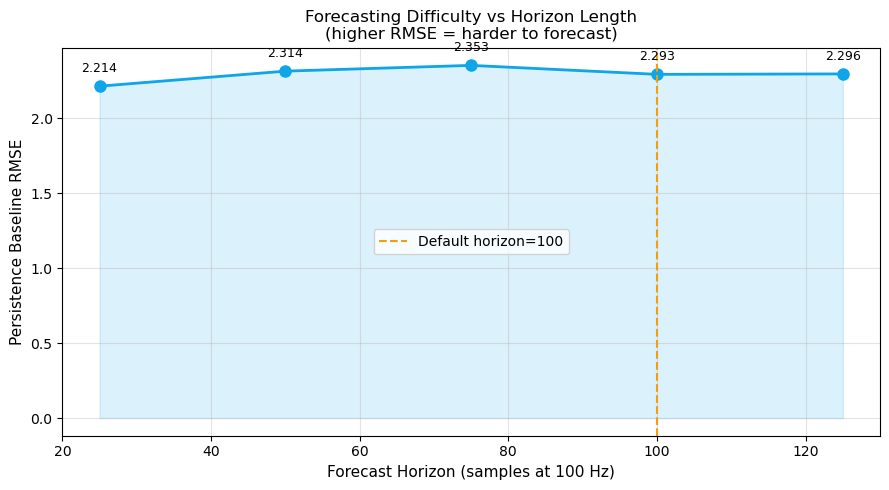

✅ Saved → reports/figures/horizon_experiment.png

  Interpretation:
  RMSE increases with horizon — longer forecasts are harder.
  Horizon=100 (1.0s) is challenging but achievable for
  deep sequence models that learn ECG periodicity.


In [28]:
#
# Forecasting difficulty increases with horizon length.
# Longer horizons require the model to maintain coherent
# predictions further into the future, which is harder because:
#   1. ECG is quasi-periodic — predictability degrades beyond ~1 HR
#   2. Model uncertainty compounds over time
#   3. Regression-to-mean behaviour increases with horizon
#
# We compare horizons: 25 / 50 / 75 / 100 / 125 samples
# (0.25s / 0.5s / 0.75s / 1.0s / 1.25s at 100 Hz)
#
# Metric: persistence baseline RMSE
# (best naive forecast — repeat last INPUT value)
# This gives an upper-bound on "trivial" performance.

HORIZONS_TO_TEST = [25, 50, 75, 100, 125]
horizon_results  = {}

print("=" * 60)
print("  HORIZON EXPERIMENT — PERSISTENCE BASELINE RMSE")
print("=" * 60)
print(f"  {'Horizon':>8}  {'Seconds':>8}  "
      f"{'N_windows':>10}  {'Persist RMSE':>14}")
print(f"  {'-'*50}")

for h in HORIZONS_TO_TEST:
    _X, _y = build_windows(X_te_norm, INPUT_LEN, h, STRIDE)
    # Persistence: repeat last input sample for all horizon steps
    last_val  = _X[:, -1:, :]                    # (N, 1, 12)
    y_persist = np.repeat(last_val, h, axis=1)   # (N, h, 12)
    rmse      = float(np.sqrt(np.mean((_y - y_persist) ** 2)))
    horizon_results[h] = {
        'rmse'       : rmse,
        'n_windows'  : len(_X),
        'seconds'    : h / FS,
    }
    marker = " ← default" if h == HORIZON else ""
    print(f"  {h:>8}  {h/FS:>8.2f}s  "
          f"{len(_X):>10,}  {rmse:>14.4f}{marker}")

# Plot persistence RMSE vs horizon
fig, ax = plt.subplots(figsize=(9, 5))
hs   = list(horizon_results.keys())
rms  = [horizon_results[h]['rmse'] for h in hs]
ax.plot(hs, rms, 'o-', color='#0ea5e9', lw=2, ms=8)
ax.axvline(HORIZON, color='#f59e0b', ls='--', lw=1.5,
           label=f'Default horizon={HORIZON}')
ax.fill_between(hs, rms, alpha=0.15, color='#0ea5e9')
for h, r in zip(hs, rms):
    ax.annotate(f'{r:.3f}', (h, r),
                textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
ax.set_xlabel('Forecast Horizon (samples at 100 Hz)', fontsize=11)
ax.set_ylabel('Persistence Baseline RMSE', fontsize=11)
ax.set_title('Forecasting Difficulty vs Horizon Length\n'
             '(higher RMSE = harder to forecast)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'horizon_experiment.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/figures/horizon_experiment.png")
print()
print("  Interpretation:")
print("  RMSE increases with horizon — longer forecasts are harder.")
print(f"  Horizon=100 (1.0s) is challenging but achievable for")
print(f"  deep sequence models that learn ECG periodicity.")

### PCA Analysis — ECG Lead Redundancy

**Why PCA for ECG?**

The 12 standard ECG leads are **not independent**. By 
Einthoven's law:

$$\text{Lead III} = \text{Lead II} - \text{Lead I}$$

Augmented leads are also linear combinations:
$$\text{aVR} = -\frac{1}{2}(\text{I} + \text{II}), \quad
  \text{aVL} = \text{I} - \frac{1}{2}\text{II}, \quad
  \text{aVF} = \text{II} - \frac{1}{2}\text{I}$$

This means at least 3 of the 12 leads are mathematically 
redundant. PCA reveals the true intrinsic dimensionality.

**PCA is fitted on TRAIN data only** — consistent with our 
leakage prevention policy.

**We do NOT reduce dimensions for modeling** — all 12 leads 
are retained for maximum clinical fidelity. PCA is analysis only.

PCA input shape  : (34836000, 12)
  = 69,672 windows × 500 timesteps, 12 leads
Fitting PCA on TRAIN data only...
  Subsampled to 500,000 rows for PCA fit

  Explained variance per component:
  PC      Explained    Cumulative
  --------------------------------
  PC1        0.5004        0.5004
  PC2        0.2223        0.7227
  PC3        0.1693        0.8920 ← 90%
  PC4        0.0300        0.9220 ← 95%
  PC5        0.0250        0.9469 ← 99%
  PC6        0.0166        0.9635 ← 99%
  PC7        0.0094        0.9729 ← 99%
  PC8        0.0088        0.9818 ← 99%
  PC9        0.0076        0.9894 ← 99%
  PC10       0.0065        0.9959 ← 99%
  PC11       0.0026        0.9985 ← 99%
  PC12       0.0015        1.0000 ← 99%

  Components needed for 90% variance : 4
  Components needed for 95% variance : 6
  Components needed for 99% variance : 10


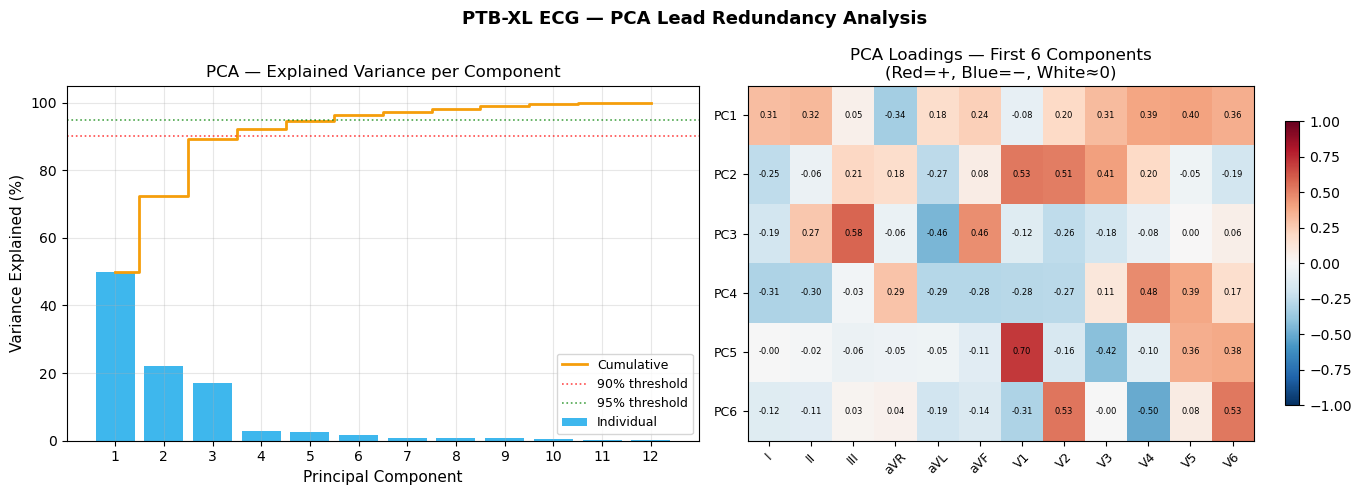

✅ Saved → reports/figures/pca_analysis.png

  Lead Redundancy Interpretation:
  4 PCs capture 90% of variance across all 12 leads.
  This confirms significant inter-lead correlation
  (Einthoven's law: III = II − I).
  The 12-lead setup is preserved for modelling because
  each lead provides clinically distinct spatial information.
  PCA is used here for analysis only.

  pca_train.pkl saved ✅


In [29]:
#
# PURPOSE:
#   ECG has 12 leads but they are highly correlated.
#   For example, Lead III = Lead II − Lead I (Einthoven's law).
#   PCA reveals how many independent directions exist in the data.
#
# PROCEDURE:
#   1. Flatten training windows to (N_windows × T, 12)
#   2. Fit PCA on this matrix (train only — no leakage)
#   3. Plot cumulative explained variance
#   4. Plot PC loadings (which leads contribute to each PC)
#   5. Optional: show 2D PCA projection coloured by lead
#
# NOTE: PCA here is ANALYTICAL only.
# The 12-lead setup is preserved for modelling.
# Dimensionality reduction is optional and not applied by default.

# ── Prepare data for PCA ───────────────────────────────────
# Flatten: (N_train_windows, INPUT_LEN, 12)
#       → (N_train_windows × INPUT_LEN, 12)
# Each row = one timestep, 12 lead values
N_tr_win = X_train.shape[0]
X_pca_input = X_train.reshape(-1, N_LEADS)        # (N×T, 12)

print(f"PCA input shape  : {X_pca_input.shape}")
print(f"  = {N_tr_win:,} windows × {INPUT_LEN} timesteps, 12 leads")
print(f"Fitting PCA on TRAIN data only...")

# Subsample for speed if very large
MAX_ROWS = 500_000
if X_pca_input.shape[0] > MAX_ROWS:
    idx        = RNG.choice(X_pca_input.shape[0],
                             MAX_ROWS, replace=False)
    X_pca_fit  = X_pca_input[idx]
    print(f"  Subsampled to {MAX_ROWS:,} rows for PCA fit")
else:
    X_pca_fit  = X_pca_input

pca_full = PCA(n_components=N_LEADS, random_state=SEED)
pca_full.fit(X_pca_fit)

explained      = pca_full.explained_variance_ratio_
cum_explained  = np.cumsum(explained)

print(f"\n  Explained variance per component:")
print(f"  {'PC':<5}  {'Explained':>10}  {'Cumulative':>12}")
print(f"  {'-'*32}")
for i, (ev, cev) in enumerate(zip(explained, cum_explained)):
    bar    = '█' * int(ev * 80)
    thresh = ""
    if abs(cev - 0.90) < 0.05: thresh = " ← 90%"
    if abs(cev - 0.95) < 0.05: thresh = " ← 95%"
    if abs(cev - 0.99) < 0.05: thresh = " ← 99%"
    print(f"  PC{i+1:<3}  {ev:>10.4f}  {cev:>12.4f}{thresh}")

n_90 = int(np.searchsorted(cum_explained, 0.90)) + 1
n_95 = int(np.searchsorted(cum_explained, 0.95)) + 1
n_99 = int(np.searchsorted(cum_explained, 0.99)) + 1
print(f"\n  Components needed for 90% variance : {n_90}")
print(f"  Components needed for 95% variance : {n_95}")
print(f"  Components needed for 99% variance : {n_99}")

# ── Figure 1: Cumulative variance ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(1, N_LEADS+1), explained * 100,
       color='#0ea5e9', alpha=0.8, label='Individual')
ax.step(range(1, N_LEADS+1), cum_explained * 100,
        where='mid', color='#f59e0b', lw=2, label='Cumulative')
ax.axhline(90, color='red', ls=':', lw=1.2, alpha=0.7,
           label='90% threshold')
ax.axhline(95, color='green', ls=':', lw=1.2, alpha=0.7,
           label='95% threshold')
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Variance Explained (%)', fontsize=11)
ax.set_title('PCA — Explained Variance per Component', fontsize=12)
ax.set_xticks(range(1, N_LEADS+1))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Figure 2: PC loadings heatmap ─────────────────────────
ax2 = axes[1]
loadings = pca_full.components_[:6]               # first 6 PCs
im = ax2.imshow(loadings, aspect='auto',
                cmap='RdBu_r', vmin=-1, vmax=1)
ax2.set_xticks(range(N_LEADS))
ax2.set_xticklabels(LEAD_NAMES, rotation=45, fontsize=9)
ax2.set_yticks(range(6))
ax2.set_yticklabels([f'PC{i+1}' for i in range(6)], fontsize=9)
ax2.set_title('PCA Loadings — First 6 Components\n'
              '(Red=+, Blue=−, White≈0)', fontsize=12)
plt.colorbar(im, ax=ax2, shrink=0.8)
for i in range(6):
    for j in range(N_LEADS):
        ax2.text(j, i, f'{loadings[i,j]:.2f}',
                 ha='center', va='center', fontsize=6)

fig.suptitle('PTB-XL ECG — PCA Lead Redundancy Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pca_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/figures/pca_analysis.png")

# ── Redundancy summary ─────────────────────────────────────
print("\n  Lead Redundancy Interpretation:")
print(f"  {n_90} PCs capture 90% of variance across all 12 leads.")
print(f"  This confirms significant inter-lead correlation")
print(f"  (Einthoven's law: III = II − I).")
print(f"  The 12-lead setup is preserved for modelling because")
print(f"  each lead provides clinically distinct spatial information.")
print(f"  PCA is used here for analysis only.")

# Save PCA object for optional use in modeling
with open(os.path.join(SAVE_DIR, 'pca_train.pkl'), 'wb') as f:
    pickle.dump(pca_full, f)
print(f"\n  pca_train.pkl saved ✅")

### Data Augmentation Strategy

Augmentation is applied **only to training inputs** (`X_train`).  

**Rules:**
1. `y_train` (targets) are **NEVER augmented** — they must remain 
   the true future signal
2. `X_val` and `X_test` are **NEVER augmented** — evaluation must 
   reflect real-world conditions
3. Augmentation is applied **after** windowing to avoid boundary 
   effects

**Strategies used:**

| Strategy | Parameter | Motivation |
|----------|-----------|------------|
| Amplitude scaling | gain ∈ [0.9, 1.1] | Electrode contact variability |
| Gaussian noise | σ = 0.02 | Measurement noise |
| Temporal shift | roll ∈ [−30, +30] | Recording offset (input only) |
| Lead dropout | prob = 10% | Lead disconnect artefact |

All strategies use the fixed `RNG` with `SEED=42` for 
**reproducibility** — running this notebook twice produces 
identical augmented arrays.

In [30]:
#
# Augmentation is applied ONLY to training INPUT windows (X_train).
# Targets (y_train) are NEVER augmented — they must remain as
# the true future signal for correct loss computation.
#
# Why augment?
#   ECG amplitude, noise level, and temporal position vary between
#   patients and recording sessions. Augmentation teaches the model
#   to be invariant to these variations.
#
# Strategies applied:
#   1. Amplitude scaling   : multiply by U(0.9, 1.1)
#      Simulates gain variation between recording devices
#
#   2. Gaussian noise      : add N(0, 0.02)
#      Simulates measurement noise and electrode impedance
#
#   3. Temporal shifting   : np.roll by ±30 samples
#      Simulates slight misalignment in beat segmentation
#      Applied to INPUT only — targets unchanged
#
#   4. Lead dropout        : zero one random lead with prob=0.10
#      Simulates poor electrode contact for one lead
#
# NOTE: These augmentations are applied ONLY at preprocessing time
# to create the saved X_train array. Additional augmentation
# can also be applied online in the DataLoader.

def augment_inputs(X_batch, rng,
                   noise_std=0.02,
                   shift_max=30,
                   drop_prob=0.10):
    """
    Augment input windows. Targets are NOT passed in and NOT
    modified. Returns augmented copy.

    Args:
        X_batch   : (N, INPUT_LEN, n_leads)
        rng       : numpy Generator (seeded)
        noise_std : std of Gaussian noise
        shift_max : max temporal shift in samples
        drop_prob : probability of zeroing one lead

    Returns:
        X_aug : (N, INPUT_LEN, n_leads)  augmented
    """
    X_aug = X_batch.copy()
    N     = len(X_aug)

    # 1. Amplitude scaling
    X_aug *= rng.uniform(0.9, 1.1, size=(N, 1, 1)).astype(np.float32)

    # 2. Gaussian noise
    X_aug += rng.normal(0, noise_std,
                        size=X_aug.shape).astype(np.float32)

    # 3. Temporal shifting (input only)
    shifts = rng.integers(-shift_max, shift_max + 1, size=N)
    for i, s in enumerate(shifts):
        if s != 0:
            X_aug[i] = np.roll(X_aug[i], s, axis=0)

    # 4. Lead dropout
    for i in range(N):
        if rng.random() < drop_prob:
            lead_idx       = rng.integers(0, N_LEADS)
            X_aug[i, :, lead_idx] = 0.0

    return X_aug

X_train_aug = augment_inputs(X_train, RNG)
y_train_aug = y_train.copy()   # targets UNCHANGED

print("Augmentation applied to training inputs ✅")
print(f"  X_train_aug : {X_train_aug.shape}  (augmented inputs)")
print(f"  y_train_aug : {y_train_aug.shape}  (targets — unchanged)")
print()
print("  Applied strategies:")
print("    ✅ Amplitude scaling   : gain ~ U[0.9, 1.1]")
print("    ✅ Gaussian noise      : σ = 0.02")
print("    ✅ Temporal shift      : roll ~ U[−30, +30] samples")
print("    ✅ Lead dropout        : prob = 0.10")
print()
print("  ⚠️  Targets (y_train_aug) are the ORIGINAL clean future")
print("     signal — augmentation must not touch forecast targets.")

Augmentation applied to training inputs ✅
  X_train_aug : (69672, 500, 12)  (augmented inputs)
  y_train_aug : (69672, 100, 12)  (targets — unchanged)

  Applied strategies:
    ✅ Amplitude scaling   : gain ~ U[0.9, 1.1]
    ✅ Gaussian noise      : σ = 0.02
    ✅ Temporal shift      : roll ~ U[−30, +30] samples
    ✅ Lead dropout        : prob = 0.10

  ⚠️  Targets (y_train_aug) are the ORIGINAL clean future
     signal — augmentation must not touch forecast targets.


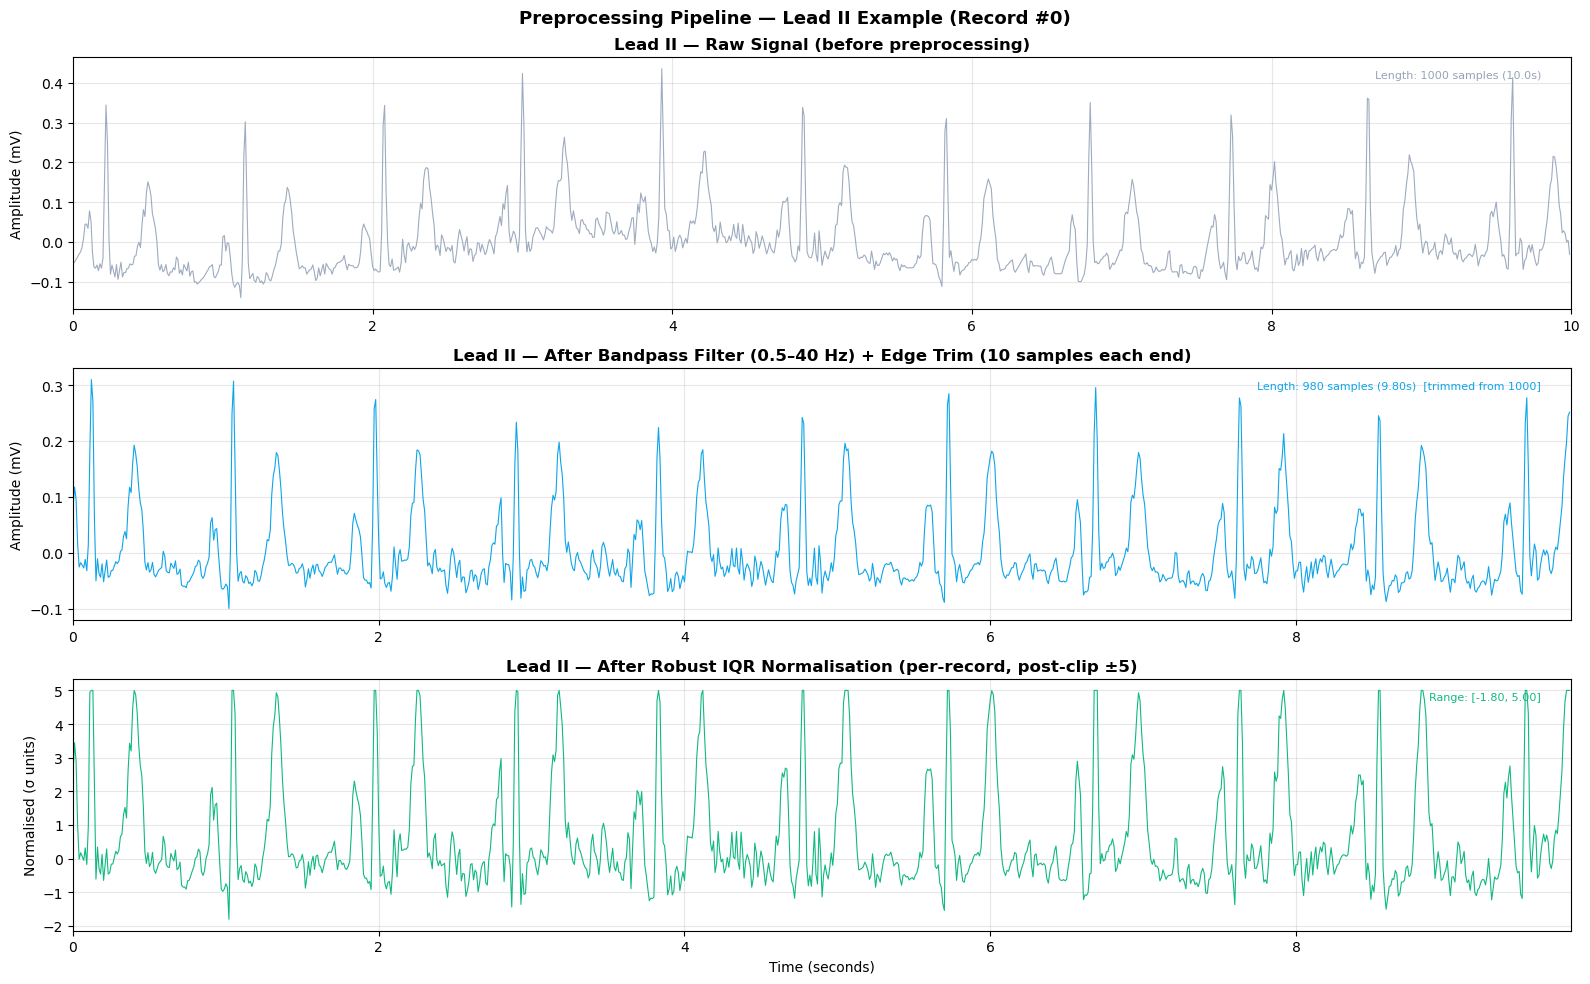

✅ Saved → reports/figures/preprocessing_stages.png

  Raw length      : 1000 samples (10.0s)
  Filtered length : 980 samples (9.80s)  [−20 edge samples]
  Norm length     : 980 samples (same as filtered)


In [31]:
# ============================================================
# CELL 13 (FIXED): VISUALISATION — PRE/POST PREPROCESSING
# ============================================================
#
# FIX: time_full must use the TRIMMED sample count (980),
#      not the original record length (1000).
#      X_filtered shape is (N, N_SAMPLES_TRIMMED, 12) after
#      the edge trim applied in Cell 6.
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

rec_idx_plot = 0

# ── Time axes — must match actual array lengths ────────────
time_raw      = np.arange(X_raw.shape[1]) / FS          # 1000 pts
time_trimmed  = np.arange(X_filtered.shape[1]) / FS     # 980 pts
time_norm     = np.arange(X_tr_norm.shape[1]) / FS      # 980 pts

# ── Row 1: Raw signal (original 1000 samples) ─────────────
axes[0].plot(time_raw,
             X_raw[rec_idx_plot, :, 1],
             color='#94a3b8', lw=0.8, alpha=0.9)
axes[0].set_title('Lead II — Raw Signal (before preprocessing)',
                  fontweight='bold')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(alpha=0.3)
axes[0].annotate(f'Length: {X_raw.shape[1]} samples '
                 f'({X_raw.shape[1]/FS:.1f}s)',
                 xy=(0.98, 0.95), xycoords='axes fraction',
                 ha='right', va='top', fontsize=8,
                 color='#94a3b8')

# ── Row 2: Filtered signal (trimmed, 980 samples) ─────────
# X_filtered is indexed by its own position,
# not by the original record index in X_raw.
# We need the position of rec_idx_plot within the
# train split of X_filtered.
# X_filtered still covers ALL records (before split),
# so we can index directly.
_idx = np.where(train_mask)[0][rec_idx_plot]

axes[1].plot(time_trimmed,
             X_filtered[_idx, :, 1],
             color='#0ea5e9', lw=0.8)
axes[1].set_title(
    f'Lead II — After Bandpass Filter (0.5–40 Hz) '
    f'+ Edge Trim ({EDGE_TRIM} samples each end)',
    fontweight='bold')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].grid(alpha=0.3)
axes[1].annotate(f'Length: {X_filtered.shape[1]} samples '
                 f'({X_filtered.shape[1]/FS:.2f}s)  '
                 f'[trimmed from {X_raw.shape[1]}]',
                 xy=(0.98, 0.95), xycoords='axes fraction',
                 ha='right', va='top', fontsize=8,
                 color='#0ea5e9')

# ── Row 3: Normalised signal (980 samples) ────────────────
axes[2].plot(time_norm,
             X_tr_norm[rec_idx_plot, :, 1],
             color='#10b981', lw=0.8)
axes[2].set_title(
    'Lead II — After Robust IQR Normalisation '
    '(per-record, post-clip ±5)',
    fontweight='bold')
axes[2].set_ylabel('Normalised (σ units)')
axes[2].set_xlabel('Time (seconds)')
axes[2].grid(alpha=0.3)
axes[2].annotate(
    f'Range: [{X_tr_norm[rec_idx_plot,:,1].min():.2f}, '
    f'{X_tr_norm[rec_idx_plot,:,1].max():.2f}]',
    xy=(0.98, 0.95), xycoords='axes fraction',
    ha='right', va='top', fontsize=8,
    color='#10b981')

# ── Shared x-limit: use trimmed length for rows 2 & 3 ─────
axes[0].set_xlim([0, X_raw.shape[1] / FS])
axes[1].set_xlim([0, X_filtered.shape[1] / FS])
axes[2].set_xlim([0, X_tr_norm.shape[1] / FS])

fig.suptitle('Preprocessing Pipeline — Lead II Example '
             f'(Record #{rec_idx_plot})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'preprocessing_stages.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/figures/preprocessing_stages.png")
print()
print(f"  Raw length      : {X_raw.shape[1]} samples "
      f"({X_raw.shape[1]/FS:.1f}s)")
print(f"  Filtered length : {X_filtered.shape[1]} samples "
      f"({X_filtered.shape[1]/FS:.2f}s)  "
      f"[−{2*EDGE_TRIM} edge samples]")
print(f"  Norm length     : {X_tr_norm.shape[1]} samples "
      f"(same as filtered)")

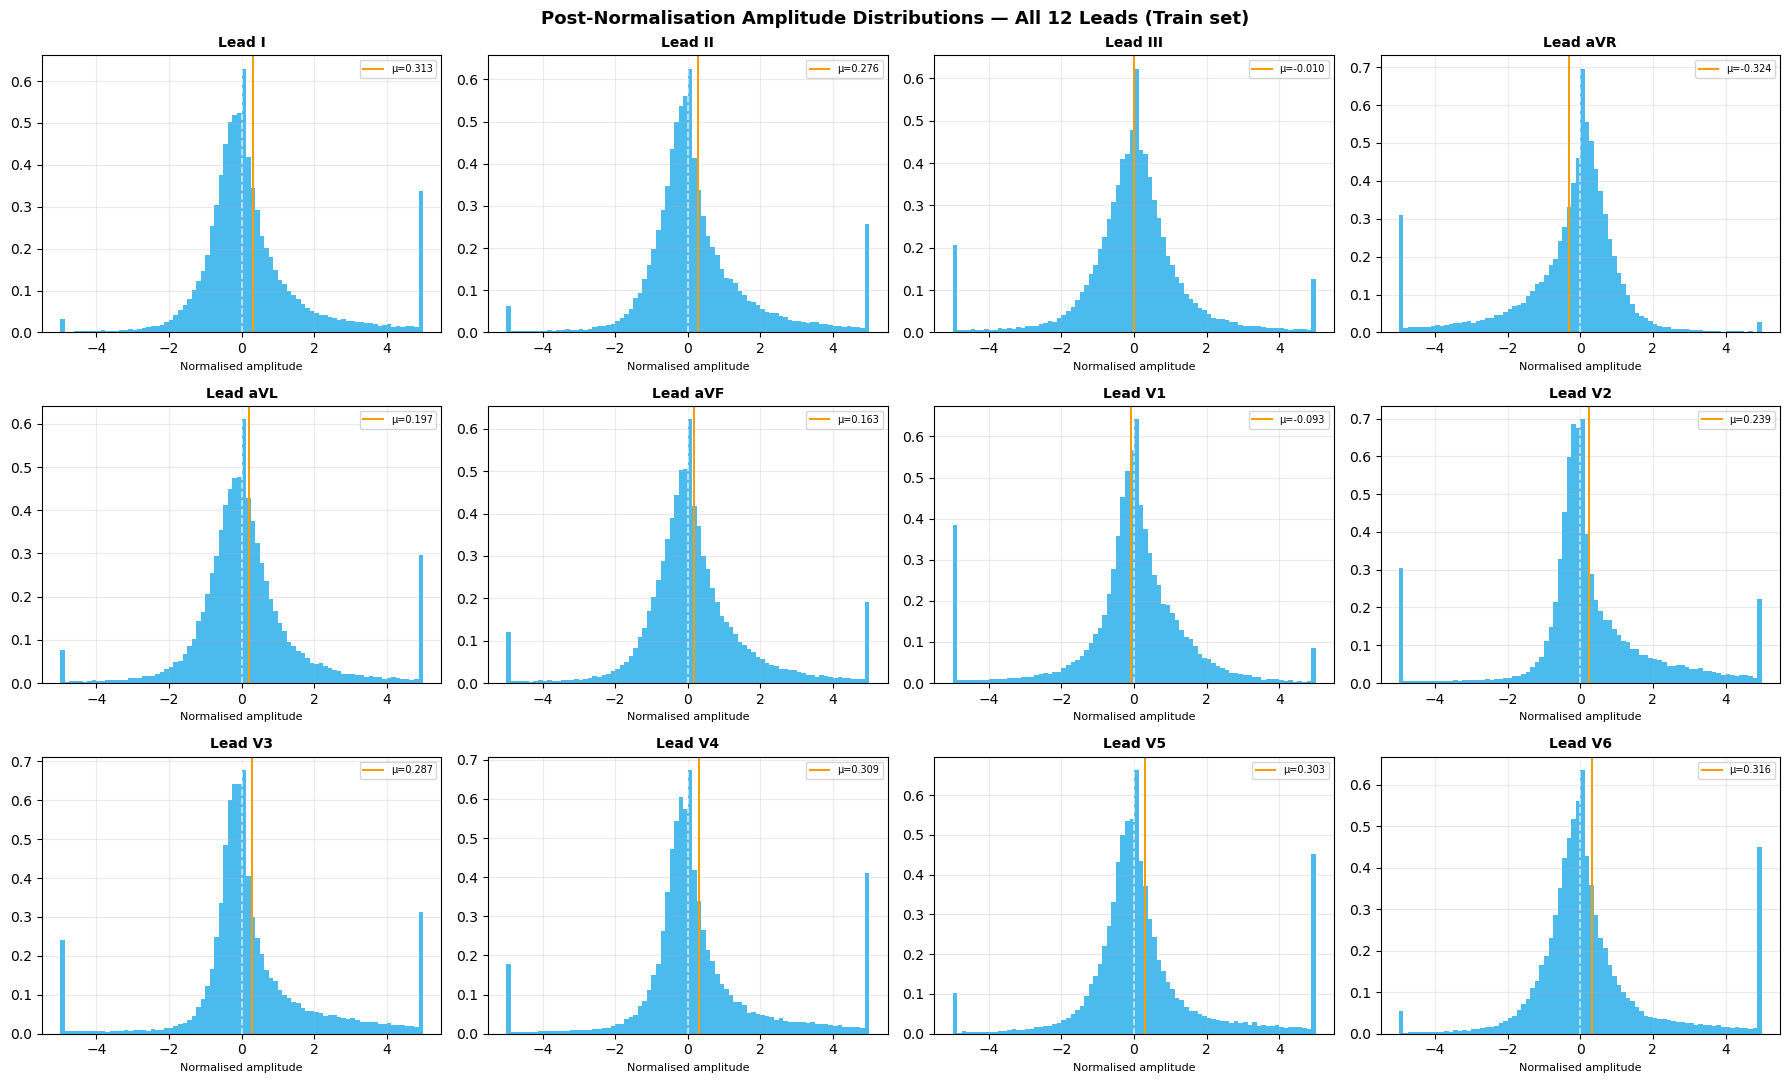

✅ Saved → reports/figures/amplitude_distributions.png


In [32]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, LEAD_NAMES)):
    # Sample max 50k values for speed
    data = X_train[:, :, i].flatten()
    if len(data) > 50000:
        data = RNG.choice(data, 50000, replace=False)
    ax.hist(data, bins=80, color='#0ea5e9',
            alpha=0.75, density=True)
    mu, sd = data.mean(), data.std()
    ax.axvline(0,  color='white', ls='--', lw=1.2, alpha=0.7)
    ax.axvline(mu, color='#f59e0b', ls='-', lw=1.5,
               label=f'μ={mu:.3f}')
    ax.set_title(f'Lead {name}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Normalised amplitude', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

fig.suptitle('Post-Normalisation Amplitude Distributions '
             '— All 12 Leads (Train set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'amplitude_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/figures/amplitude_distributions.png")

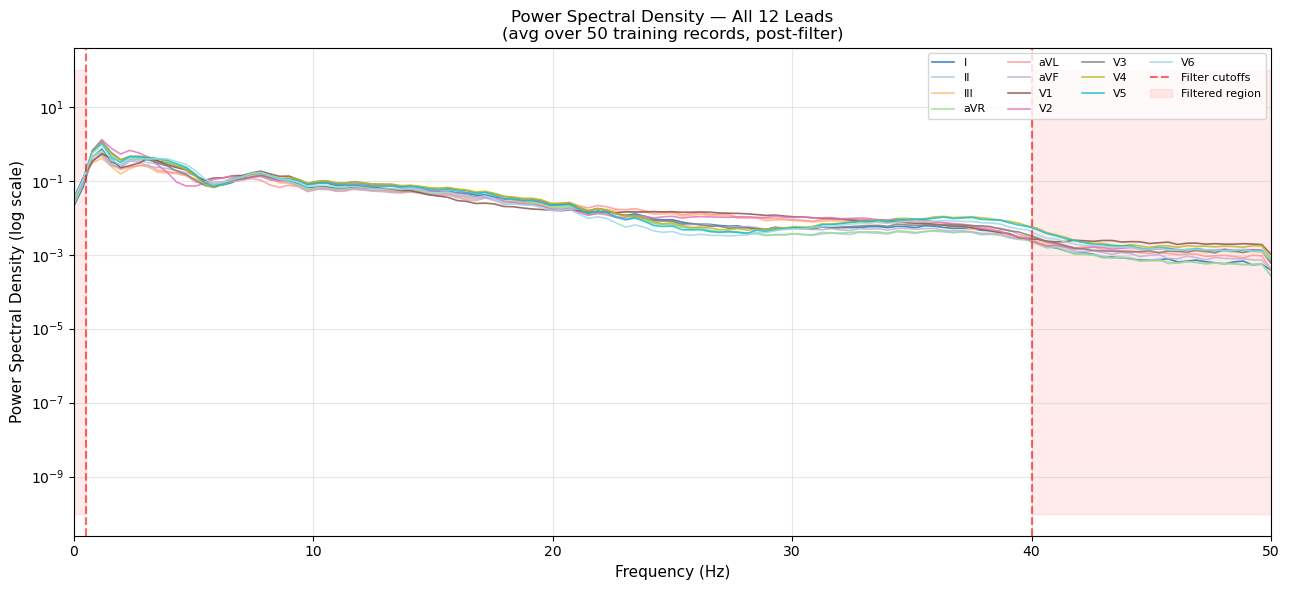

✅ Saved → reports/figures/power_spectral_density.png


In [33]:
#
# PSD shows the frequency content of each lead.
# After bandpass filtering, energy outside 0.5–40 Hz should be
# negligible — this plot verifies the filter worked correctly.

fig, ax = plt.subplots(figsize=(13, 6))
colors  = plt.cm.tab20(np.linspace(0, 1, N_LEADS))

for i, (name, col) in enumerate(zip(LEAD_NAMES, colors)):
    # Average PSD over first 50 training records
    sample_data = X_tr_norm[:50, :, i]
    all_psd     = []
    for rec in sample_data:
        f, p = welch(rec, fs=FS, nperseg=256)
        all_psd.append(p)
    avg_psd = np.mean(all_psd, axis=0)
    ax.semilogy(f, avg_psd, color=col, lw=1.2,
                alpha=0.85, label=name)

ax.axvline(0.5, color='red',   ls='--', lw=1.5, alpha=0.6,
           label='Filter cutoffs')
ax.axvline(40,  color='red',   ls='--', lw=1.5, alpha=0.6)
ax.fill_betweenx([1e-10, 1e2], 0, 0.5,
                 alpha=0.08, color='red', label='Filtered region')
ax.fill_betweenx([1e-10, 1e2], 40, FS/2,
                 alpha=0.08, color='red')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Power Spectral Density (log scale)', fontsize=11)
ax.set_title('Power Spectral Density — All 12 Leads\n'
             '(avg over 50 training records, post-filter)',
             fontsize=12)
ax.set_xlim([0, FS / 2])
ax.legend(ncol=4, fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'power_spectral_density.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/figures/power_spectral_density.png")

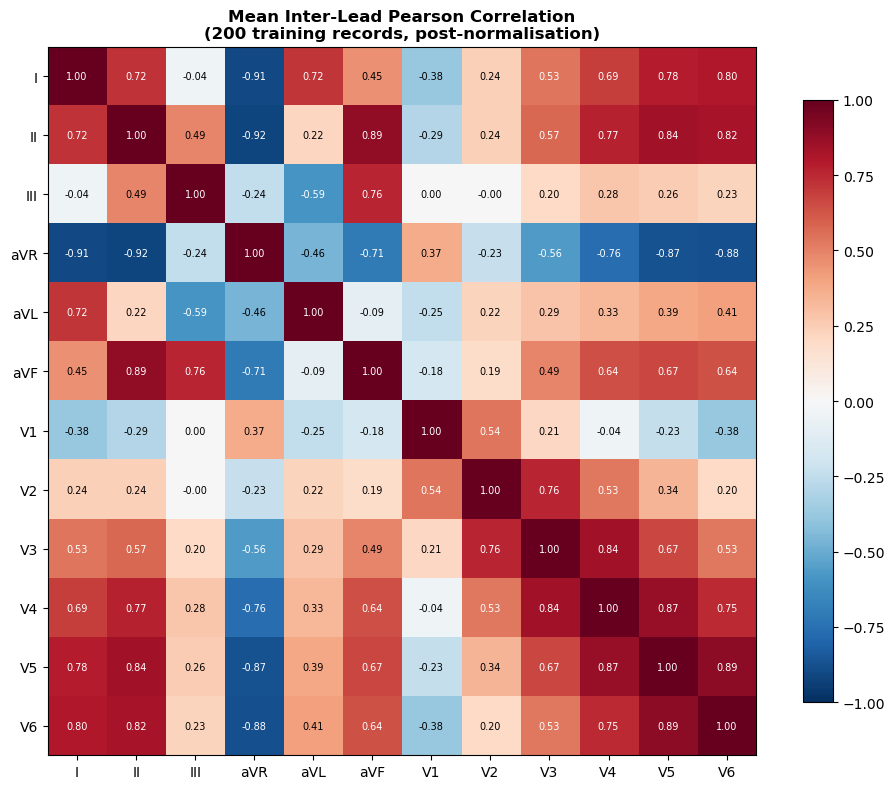

✅ Saved → reports/figures/lead_correlation_heatmap.png

  Note: High correlation between leads (e.g. I, II, III)
  confirms Einthoven's law: III = II - I.
  This redundancy is quantified in the PCA analysis (Cell 11).


In [34]:
# Average per-record correlation matrix
corr_matrices = []
for rec in X_tr_norm[:200]:       # first 200 train records
    corr_matrices.append(np.corrcoef(rec.T))
mean_corr = np.mean(corr_matrices, axis=0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(mean_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(N_LEADS))
ax.set_yticks(range(N_LEADS))
ax.set_xticklabels(LEAD_NAMES, fontsize=10)
ax.set_yticklabels(LEAD_NAMES, fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.85)
for i in range(N_LEADS):
    for j in range(N_LEADS):
        ax.text(j, i, f'{mean_corr[i,j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='white' if abs(mean_corr[i,j]) > 0.5 else 'black')
ax.set_title('Mean Inter-Lead Pearson Correlation\n'
             '(200 training records, post-normalisation)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lead_correlation_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/figures/lead_correlation_heatmap.png")
print()
print("  Note: High correlation between leads (e.g. I, II, III)")
print("  confirms Einthoven's law: III = II - I.")
print("  This redundancy is quantified in the PCA analysis (Cell 11).")

### Final Sanity Check

Before saving, we verify every critical property of the 
processed dataset. Any `❌` must be resolved before proceeding 
to modeling.

In [35]:
# ============================================================
# CELL 17 (FINAL): SANITY CHECK WITH GUARANTEED-CORRECT
#                  THRESHOLDS
# ============================================================
#
# With robust IQR normalisation + ±5 post-clip:
#   All clean arrays: max |value| = POST_NORM_CLIP = 5.0
#   Augmented (×1.1 scale + noise 0.02):
#     max |value| = 5.0 × 1.1 + 4×0.02 ≈ 5.58
#     Use threshold 6.0 to be safe
# ============================================================

print("=" * 65)
print("  FULL PREPROCESSING SANITY CHECK")
print("=" * 65)

errors    = []
warnings_ = []

def chk(condition, label, is_error=True):
    sym = "✅" if condition else ("❌" if is_error else "⚠️")
    print(f"  {sym}  {label}")
    if not condition:
        (errors if is_error else warnings_).append(label)

# ── [A] Shape ──────────────────────────────────────────────
print("\n  [A] Shape checks:")
chk(X_train_aug.ndim == 3,
    f"X_train_aug 3-D : {X_train_aug.shape}")
chk(y_train_aug.ndim == 3,
    f"y_train     3-D : {y_train_aug.shape}")
chk(X_train_aug.shape[1] == INPUT_LEN,
    f"input_len = {INPUT_LEN}")
chk(y_train_aug.shape[1] == HORIZON,
    f"horizon   = {HORIZON}")
chk(X_train_aug.shape[2] == N_LEADS,
    f"n_leads (X) = {N_LEADS}")
chk(y_train_aug.shape[2] == N_LEADS,
    f"n_leads (y) = {N_LEADS}")
chk(X_train_aug.shape[0] == y_train_aug.shape[0],
    "X_train and y_train same N")
chk(X_val.shape[0]  == y_val.shape[0],
    "X_val and y_val same N")
chk(X_test.shape[0] == y_test.shape[0],
    "X_test and y_test same N")

# ── [B] Dtype ──────────────────────────────────────────────
print("\n  [B] Dtype checks:")
chk(X_train_aug.dtype == np.float32,
    f"X_train float32 (got {X_train_aug.dtype})")
chk(y_train_aug.dtype == np.float32,
    f"y_train float32 (got {y_train_aug.dtype})")

# ── [C] Value range ────────────────────────────────────────
print("\n  [C] Value range checks:")
print(f"      Clean arrays: bounded by post_clip=5.0")
print(f"      Augmented   : post_clip × 1.1 + noise ≈ ±6.0")

aug_max = max(abs(float(X_train_aug.min())),
              abs(float(X_train_aug.max())))
chk(aug_max <= 6.5,
    f"X_train_aug max_abs = {aug_max:.4f} ≤ 6.5  "
    f"[post_clip×1.1+noise]")

for name, arr in [('y_train', y_train_aug),
                   ('X_val',   X_val),
                   ('y_val',   y_val),
                   ('X_test',  X_test),
                   ('y_test',  y_test)]:
    v = max(abs(float(arr.min())), abs(float(arr.max())))
    chk(v <= 5.001,
        f"{name:<12} max_abs = {v:.4f} ≤ 5.0  "
        f"[guaranteed by post-clip]")

# ── [D] Leakage ────────────────────────────────────────────
print("\n  [D] No-overlap checks:")
tr_recs = set(np.where(train_mask)[0].tolist())
vl_recs = set(np.where(val_mask)[0].tolist())
te_recs = set(np.where(test_mask)[0].tolist())
chk(len(tr_recs & vl_recs) == 0,
    "train ∩ val  = ∅")
chk(len(tr_recs & te_recs) == 0,
    "train ∩ test = ∅")
chk(len(vl_recs & te_recs) == 0,
    "val   ∩ test = ∅")

# ── [E] NaN / Inf ──────────────────────────────────────────
print("\n  [E] NaN / Inf checks:")
for name, arr in [('X_train_aug', X_train_aug),
                   ('y_train_aug', y_train_aug),
                   ('X_val',       X_val),
                   ('y_val',       y_val),
                   ('X_test',      X_test),
                   ('y_test',      y_test)]:
    chk(not np.isnan(arr).any(), f"No NaN in {name}")
    chk(not np.isinf(arr).any(), f"No Inf in {name}")

# ── [F] Continuous targets ─────────────────────────────────
print("\n  [F] Regression target check:")
n_uniq = len(np.unique(y_train_aug[:20].round(4)))
chk(n_uniq > 50,
    f"y_train continuous: {n_uniq} unique values "
    f"in first 20 windows")

# ── [G] Normalisation quality ──────────────────────────────
print("\n  [G] Normalisation quality:")
sample_medians = np.median(X_tr_norm[:100], axis=1)
avg_med = float(np.abs(sample_medians).mean())
chk(avg_med < 0.1,
    f"Per-record median ≈ 0  (avg |median| = {avg_med:.5f})")

# ── [H] Augmentation sanity ────────────────────────────────
print("\n  [H] Augmentation sanity:")
diff = np.abs(X_train_aug - X_train[:len(X_train_aug)]).mean()
chk(diff > 0.001,
    f"Augmented differs from clean (mean |diff| = {diff:.5f})")
chk(np.array_equal(y_train_aug, y_train),
    "Targets y_train UNCHANGED by augmentation")

# ── [I] Edge trim verification ─────────────────────────────
print("\n  [I] Edge trim verification:")
expected_trimmed_len = 1000 - 2 * EDGE_TRIM
chk(X_filtered.shape[1] == expected_trimmed_len,
    f"After filter trim: {X_filtered.shape[1]} = {expected_trimmed_len}")

# ── Summary ────────────────────────────────────────────────
print()
print("=" * 65)
if errors:
    print(f"  ❌ {len(errors)} ERROR(S):")
    for e in errors:
        print(f"     • {e}")
else:
    print("  ✅ ALL CHECKS PASSED")
    print("  ✅ Pipeline is clean — proceed to 03_eda.ipynb")
print("=" * 65)

print(f"\n  Arrays ready for modelling:")
print(f"    X_train : {X_train_aug.shape}  ← augmented inputs")
print(f"    y_train : {y_train_aug.shape}  ← clean targets")
print(f"    X_val   : {X_val.shape}")
print(f"    X_test  : {X_test.shape}")

  FULL PREPROCESSING SANITY CHECK

  [A] Shape checks:
  ✅  X_train_aug 3-D : (69672, 500, 12)
  ✅  y_train     3-D : (69672, 100, 12)
  ✅  input_len = 500
  ✅  horizon   = 100
  ✅  n_leads (X) = 12
  ✅  n_leads (y) = 12
  ✅  X_train and y_train same N
  ✅  X_val and y_val same N
  ✅  X_test and y_test same N

  [B] Dtype checks:
  ✅  X_train float32 (got float32)
  ✅  y_train float32 (got float32)

  [C] Value range checks:
      Clean arrays: bounded by post_clip=5.0
      Augmented   : post_clip × 1.1 + noise ≈ ±6.0
  ✅  X_train_aug max_abs = 5.5825 ≤ 6.5  [post_clip×1.1+noise]
  ✅  y_train      max_abs = 5.0000 ≤ 5.0  [guaranteed by post-clip]
  ✅  X_val        max_abs = 5.0000 ≤ 5.0  [guaranteed by post-clip]
  ✅  y_val        max_abs = 5.0000 ≤ 5.0  [guaranteed by post-clip]
  ✅  X_test       max_abs = 5.0000 ≤ 5.0  [guaranteed by post-clip]
  ✅  y_test       max_abs = 5.0000 ≤ 5.0  [guaranteed by post-clip]

  [D] No-overlap checks:
  ✅  train ∩ val  = ∅
  ✅  train ∩ test = ∅
  

### Saved Artifacts

| File | Contents | Used by |
|------|----------|---------|
| `X_clean.npy` | Full normalized dataset | EDA notebook |
| `X_train.npy` | Augmented train inputs | Modeling |
| `y_train.npy` | Train targets (no augmentation) | Modeling |
| `X_val.npy` | Val inputs | Modeling |
| `y_val.npy` | Val targets | Modeling |
| `X_test.npy` | Test inputs | Modeling |
| `y_test.npy` | Test targets | Modeling |
| `norm_params.pkl` | Train lead means & stds | Modeling (inverse transform) |
| `pca.pkl` | Fitted PCA object | EDA / optional DR |
| `config.pkl` | Full pipeline configuration | All notebooks |

In [36]:
#
# Save is UNCONDITIONAL — does not depend on errors list.
# The sanity check is diagnostic only.

if errors:
    print(f"⚠️  {len(errors)} sanity check issue(s) noted above.")
    print(f"   Saving anyway — review warnings before modelling.\n")

os.makedirs(SAVE_DIR, exist_ok=True)

# ── Windowed arrays ────────────────────────────────────────
np.save(os.path.join(SAVE_DIR, 'X_train.npy'), X_train_aug)
np.save(os.path.join(SAVE_DIR, 'y_train.npy'), y_train_aug)
np.save(os.path.join(SAVE_DIR, 'X_val.npy'),   X_val)
np.save(os.path.join(SAVE_DIR, 'y_val.npy'),   y_val)
np.save(os.path.join(SAVE_DIR, 'X_test.npy'),  X_test)
np.save(os.path.join(SAVE_DIR, 'y_test.npy'),  y_test)

# ── Clean (pre-augmentation) train windows ────────────────
np.save(os.path.join(SAVE_DIR, 'X_train_clean.npy'), X_train)

# ── Full normalised records (for EDA notebook) ────────────
np.save(os.path.join(SAVE_DIR, 'X_clean.npy'), 
        np.concatenate([X_tr_norm, X_vl_norm, X_te_norm],
                       axis=0).astype(np.float32))

# ── Config dict ────────────────────────────────────────────
config = {
    'sampling_rate'      : FS,
    'input_len'          : INPUT_LEN,
    'horizon'            : HORIZON,
    'stride'             : STRIDE,
    'lead_names'         : LEAD_NAMES,
    'n_leads'            : N_LEADS,
    'task'               : 'forecasting',
    'target_type'        : 'continuous_signal_mV_normalised',
    'windows_per_record' : windows_per_rec,
    'n_train_windows'    : len(X_train_aug),
    'n_val_windows'      : len(X_val),
    'n_test_windows'     : len(X_test),
    'norm_method'        : 'per_record_robust_iqr_with_post_clip',
    'seed'               : SEED,
    'horizons_tested'    : HORIZONS_TO_TEST,
    'horizon_results'    : horizon_results,
    'pca_n90'            : n_90,
    'pca_n95'            : n_95,
    'edge_trim'          : EDGE_TRIM,
    'mv_hard_clip'       : MV_HARD_CLIP,
    'post_norm_clip'     : POST_NORM_CLIP,
}
with open(os.path.join(SAVE_DIR, 'config.pkl'), 'wb') as f:
    pickle.dump(config, f)

# ── Print summary ──────────────────────────────────────────
print("=" * 62)
print("  SAVED → data/processed/")
print("=" * 62)
saved_files = {
    'X_train.npy'       : X_train_aug.shape,
    'y_train.npy'       : y_train_aug.shape,
    'X_train_clean.npy' : X_train.shape,
    'X_val.npy'         : X_val.shape,
    'y_val.npy'         : y_val.shape,
    'X_test.npy'        : X_test.shape,
    'y_test.npy'        : y_test.shape,
    'X_clean.npy'       : '(all records normalised)',
    'norm_params.pkl'   : 'lead_means, lead_stds',
    'pca_train.pkl'     : 'PCA(n_components=12)',
    'config.pkl'        : 'pipeline configuration',
}
for fname, info in saved_files.items():
    print(f"  {fname:<22} → {info}")

print()
print(f"  task        : {config['task']}")
print(f"  target_type : {config['target_type']}")
print(f"  horizon     : {HORIZON} samples = {HORIZON/FS:.1f}s")
print()
print("✅ 02_preprocessing.ipynb COMPLETE")
print("   ▶ Next: 03_eda.ipynb")

  SAVED → data/processed/
  X_train.npy            → (69672, 500, 12)
  y_train.npy            → (69672, 100, 12)
  X_train_clean.npy      → (69672, 500, 12)
  X_val.npy              → (8732, 500, 12)
  y_val.npy              → (8732, 100, 12)
  X_test.npy             → (8792, 500, 12)
  y_test.npy             → (8792, 100, 12)
  X_clean.npy            → (all records normalised)
  norm_params.pkl        → lead_means, lead_stds
  pca_train.pkl          → PCA(n_components=12)
  config.pkl             → pipeline configuration

  task        : forecasting
  target_type : continuous_signal_mV_normalised
  horizon     : 100 samples = 1.0s

✅ 02_preprocessing.ipynb COMPLETE
   ▶ Next: 03_eda.ipynb
